<a href="https://colab.research.google.com/github/sakshijadhav-08/AIML-Session-27-Clustering-and-PCA/blob/main/26_Q10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

In [ ]:
print("Head:",df.head(),"\n")

print("Info:",df.info(),"\n")

print("Describe",df.describe(),"\n")

Head:    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Cluster            150 non-null    int32  

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [ ]:
wss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(scaled_data)

    wss.append(model.inertia_)

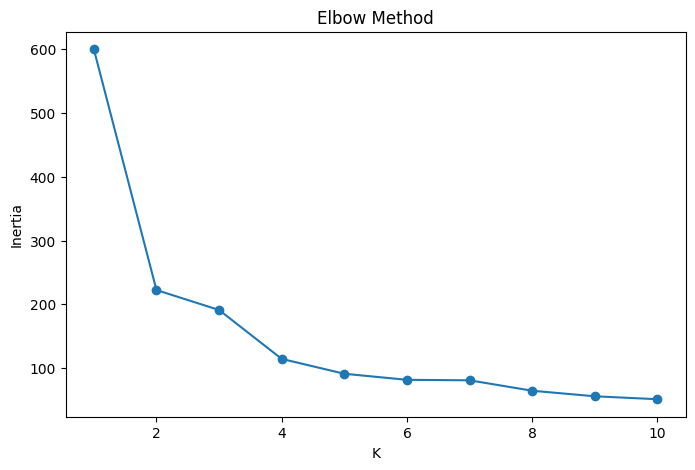

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wss, marker='o')

plt.title("Elbow Method")

plt.xlabel("K")

plt.ylabel("Inertia")

plt.show()

In [ ]:
model = KMeans(
    n_clusters=3,
    random_state=42
)

df["Cluster"] = model.fit_predict(scaled_data)

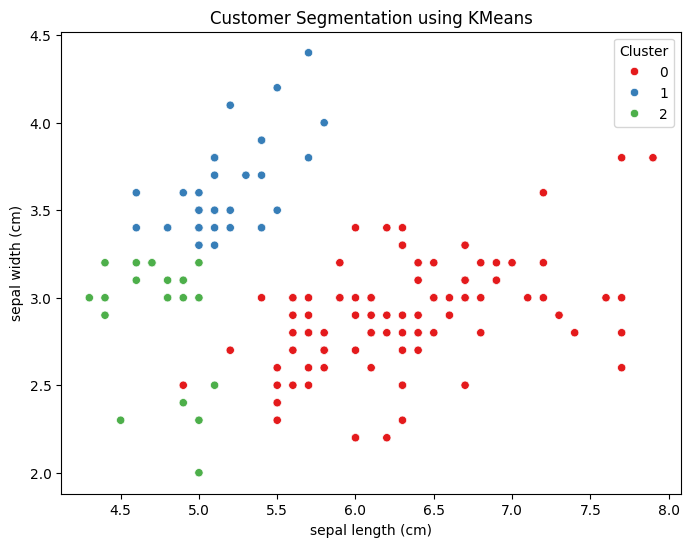

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="Cluster",
    palette="Set1"
)

plt.title("K-Means Clustering on Iris Dataset")

plt.show()